
# 03 — การสุ่มค่าภูมิประเทศตามลำบีมเรดาร์และการสร้าง Terrain–Beam Profiles
## Terrain Sampling and Terrain–Beam Profiles

**Google Colab teaching notebook | Geography · Geoinformatics · Environmental Science · Radar Meteorology**

Notebook นี้ต่อจาก

- **00 — Setup and Download SRTM DEM**
- **01 — SRTM DEM Preprocessing for Radar–Terrain Analysis**
- **02 — Radar Beam Geometry for Terrain Analysis**

ใน Notebook 02 เราศึกษาเฉพาะ geometry ของลำบีม โดยยังไม่ให้ลำบีมมีปฏิสัมพันธ์กับภูมิประเทศ

Notebook นี้จะนำสองระบบข้อมูลมาพบกันเป็นครั้งแรก:

$$
\boxed{
H_{\mathrm{terrain}}(r,\alpha)
\quad\text{กับ}\quad
H_{\mathrm{beam}}(r,\theta)
}
$$

เป้าหมายหลักคือให้นิสิตเข้าใจว่า **DEM ซึ่งเดิมเป็น raster แบบ Cartesian/UTM สามารถถูก sample ให้อยู่บน radar-centric polar geometry ได้อย่างไร** และภูเขาหรือ ridge ในแต่ละ azimuth มีตำแหน่งสัมพันธ์กับ beam centre และ beam edges อย่างไร

> **สำคัญ:** Notebook นี้ยัง **ไม่คำนวณ PBB หรือ CBB**  
> การที่ terrain ตัด lower beam edge เป็นเพียง **geometric penetration** ไม่ใช่ beam-blockage fraction



### รูปแบบสมการสำหรับ Google Colab

Notebook นี้ใช้ MathJax/LaTeX แบบเดียวกับบทก่อนหน้า

- สมการในบรรทัดใช้ `$ ... $`
- สมการแยกบรรทัดใช้ `$$ ... $$`

เพื่อให้สมการแสดงผลได้เสถียรใน Google Colab



## 1. คำถามนำของบทเรียน

ก่อนรันโค้ด ลองพิจารณา:

1. DEM แบบ UTM raster จะถูกแปลงเป็นข้อมูลแบบ **azimuth × range** ของ radar ได้อย่างไร?
2. ถ้า azimuth $0^\circ$ คือทิศเหนือ และ $90^\circ$ คือทิศตะวันออก เราจะคำนวณพิกัด UTM ของแต่ละ radar gate อย่างไร?
3. เหตุใดการ sample terrain สำหรับ 1-km MAX DEM จึงควรหลีกเลี่ยงการ smooth ซ้ำโดยไม่จำเป็น?
4. ภูเขาที่ไม่สูงถึง beam centre ยังสามารถรบกวนลำบีมได้หรือไม่?
5. ความหมายของ **beam-centre clearance** และ **lower-edge clearance** ต่างกันอย่างไร?
6. หาก terrain ตัด lower −3 dB beam edge เราสามารถเรียกว่า CBB ได้หรือยัง?
7. เหตุใดการเลือกสถานี radar ไม่ควรดูเพียง ground elevation ของ candidate site?



## 2. Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ

- อธิบายการเปลี่ยนจาก **UTM raster coordinates** ไปเป็น **radar polar sampling geometry**
- ใช้ azimuth convention แบบอุตุนิยมวิทยา: $0^\circ=$ North และ $90^\circ=$ East
- คำนวณพิกัด Easting/Northing ของ radar gates
- แยก **slant range** ออกจาก **ground-arc distance**
- sample 1-km DEM ตาม radar rays โดยไม่ smooth terrain ซ้ำ
- สร้าง terrain matrix ในรูป

$$
T(\alpha,r)
$$

- สร้าง terrain–beam profile สำหรับ selected azimuths
- คำนวณ geometric clearance ของ beam centre และ lower −3 dB edge
- ระบุ first geometric intersection และ minimum clearance
- อธิบายว่าทำไม terrain penetration ยังไม่เท่ากับ PBB/CBB
- เตรียม terrain-sampling product สำหรับ Notebook 04



# Part A — จาก DEM Raster สู่ Radar Polar Coordinates

## 3. DEM ใน Cartesian Coordinates

DEM จาก Notebook 01 อยู่ใน **EPSG:32647 — WGS 84 / UTM Zone 47N**

ดังนั้นแต่ละ raster cell มีตำแหน่ง

$$
(E,N)
$$

ในหน่วย metre

โดย

- $E$ = Easting
- $N$ = Northing

และ DEM ให้ระดับภูมิประเทศ

$$
H_{\mathrm{terrain}}(E,N)
$$

ในหน่วย metre MSL



## 4. Radar-centric Polar Coordinates

Radar ใช้ระบบพิกัด

$$
(s,\alpha,\theta)
$$

โดย

- $s$ = slant range
- $\alpha$ = azimuth
- $\theta$ = elevation angle

สำหรับการหาตำแหน่งบนพื้น เราใช้ ground distance $d$ ที่สอดคล้องกับ slant range และ elevation

เมื่อกำหนด azimuth แบบอุตุนิยมวิทยา

$$
0^\circ = \mathrm{North}
$$

$$
90^\circ = \mathrm{East}
$$

พิกัดของ radar gate บน UTM grid สามารถประมาณได้จาก

$$
E
=
E_0
+
d\sin\alpha
$$

$$
N
=
N_0
+
d\cos\alpha
$$

โดย $(E_0,N_0)$ คือพิกัด radar site

สังเกตว่าใช้ $\sin\alpha$ กับ Easting และ $\cos\alpha$ กับ Northing เพราะ azimuth เริ่มวัดจาก **ทิศเหนือ** ไม่ใช่จากแกน $x$ แบบคณิตศาสตร์ทั่วไป



## 5. Slant Range กับ Ground Distance

ใน Notebook 02 เรากำหนด radar gates ด้วย slant range

$$
s_i
=
\left(i+\frac{1}{2}\right)\Delta r
$$

แต่จุดที่เราต้อง sample DEM อยู่บนพื้นผิวโลก

ภายใต้ effective-Earth-radius model เราจึงคำนวณ ground-arc distance จาก

$$
d
=
kR_e
\tan^{-1}
\left[
\frac{
s\cos\theta
}{
kR_e+s\sin\theta
}
\right]
$$

สำหรับ elevation ต่ำ ความต่างระหว่าง $s$ และ $d$ ไม่มาก แต่การแยกสองปริมาณนี้ช่วยให้นิสิตเข้าใจ geometry ได้ถูกต้อง



## 6. การ Sampling DEM

หลังจากได้ตำแหน่ง gate

$$
(E_{ij},N_{ij})
$$

เราจะหา raster cell ที่ครอบคลุมตำแหน่งนั้น และดึงค่าระดับภูมิประเทศ

$$
T_{ij}
=
DEM(E_{ij},N_{ij})
$$

จึงได้ matrix

$$
T(\alpha,r)
$$

สำหรับ

$$
360\ \mathrm{azimuths}
\times
480\ \mathrm{range\ gates}
$$

หรือทั้งหมด

$$
172{,}800
$$

terrain samples ต่อ site และ reference elevation

### ทำไมใช้ nearest raster-cell sampling?

DEM ที่ใช้เป็น **1-km MAX-elevation DEM** ซึ่งผ่านการ aggregate มาแล้วเพื่อรักษา terrain maxima

หากทำ bilinear interpolation อีกครั้ง อาจเกิดการ smooth ridge ซ้ำ

ดังนั้นในบทนี้เราจะใช้ค่าของ raster cell ที่ตำแหน่ง gate ตกอยู่โดยตรง เพื่อรักษา conservative terrain representation ของ 1-km MAX DEM



# Part B — Terrain–Beam Interaction

## 7. Beam Centre และ Beam Edges

สำหรับ nominal elevation $\theta$ และ beamwidth $\beta$

$$
\theta_{\mathrm{lower}}
=
\theta-\frac{\beta}{2}
$$

$$
\theta_{\mathrm{upper}}
=
\theta+\frac{\beta}{2}
$$

ระดับของแต่ละเส้นเหนือ antenna คำนวณด้วย effective-Earth-radius beam equation จาก Notebook 02

จากนั้นแปลงเป็นระดับ MSL:

$$
H_{\mathrm{beam,MSL}}
=
H_{\mathrm{antenna,MSL}}
+
h_{\mathrm{beam}}
$$



## 8. Geometric Clearance

เรานิยาม beam-centre clearance:

$$
C_{\mathrm{center}}
=
H_{\mathrm{beam,center}}
-
H_{\mathrm{terrain}}
$$

และ lower-edge clearance:

$$
C_{\mathrm{lower}}
=
H_{\mathrm{beam,lower}}
-
H_{\mathrm{terrain}}
$$

การตีความ:

- $C>0$ : terrain อยู่ต่ำกว่าเส้นที่พิจารณา
- $C=0$ : terrain สัมผัสเส้น
- $C<0$ : terrain สูงกว่าเส้นนั้น

ดังนั้นหาก

$$
C_{\mathrm{lower}}<0
$$

terrain ได้ทะลุเข้าสู่ half-power beam envelope แล้ว

แต่ยัง **ห้ามเรียกค่านี้ว่า PBB หรือ CBB** เพราะ PBB ต้องคำนวณสัดส่วนหน้าตัดของ beam ที่ถูกบัง และ CBB ต้องคำนึงถึง cumulative obstruction ตามแนว ray



## 9. Vertical Reference ต้องสอดคล้องกัน

DEM ของ workflow นี้ใช้ elevation ที่อ้างอิงกับ mean-sea-level/geoid framework ของ source SRTM

ในการวิเคราะห์เชิงวิศวกรรมจริง:

$$
H_{\mathrm{antenna,MSL}}
=
H_{\mathrm{surveyed\ ground,MSL}}
+
H_{\mathrm{antenna,AGL}}
$$

ถ้าความสูงจาก GNSS เป็น ellipsoidal height ต้องตรวจและแปลงให้อยู่ใน vertical reference ที่สอดคล้องกับ DEM ก่อนเปรียบเทียบ

ในแบบเรียนนี้ยังใช้ native DEM ground elevation และ antenna-height teaching assumption จาก Notebook 02


In [1]:

# ============================================================
# STEP 1 — Install only packages that may be missing
# ============================================================

import sys
import subprocess
import importlib.util

required_packages = {
    "rasterio": "rasterio",
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name,
        ])

print("✓ Package check complete")


✓ Package check complete


In [2]:

# ============================================================
# STEP 2 — Imports and software environment
# ============================================================

from pathlib import Path
import json
import math
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

import rasterio
from rasterio.transform import rowcol
from matplotlib.patches import Circle

print("Software environment")
print("--------------------")
print("Python      :", platform.python_version())
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", plt.matplotlib.__version__)
print("Rasterio    :", rasterio.__version__)


Software environment
--------------------
Python      : 3.13.15
NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.0
Rasterio    : 1.5.1


In [3]:

# ============================================================
# STEP 3 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [4]:

# ============================================================
# STEP 4 — Course paths and visual conventions
# ============================================================

COURSE_ROOT = Path(
    "/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage"
)

PROCESSED_DEM_DIR = COURSE_ROOT / "01_processed_data" / "dem"
METADATA_DIR = COURSE_ROOT / "02_metadata"
RESULTS_DIR = COURSE_ROOT / "03_results"
FIGURES_DIR = COURSE_ROOT / "04_figures"
TABLES_DIR = COURSE_ROOT / "05_tables"

for p in [
    METADATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

DEM_PATH = (
    PROCESSED_DEM_DIR /
    "Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif"
)

SITE_CSV = (
    METADATA_DIR /
    "01_site_elevation_native_vs_1km_MAX.csv"
)

GEOMETRY_JSON = (
    METADATA_DIR /
    "02_radar_beam_geometry_parameters.json"
)

# ------------------------------------------------------------
# Course-wide visual standards
# ------------------------------------------------------------
DEM_CMAP = "terrain"

BLOCKAGE_CMAP = "PuRd"
BLOCKAGE_VMIN = 0.0
BLOCKAGE_VMAX = 1.0

CURRENT_MARKER = "*"
CURRENT_FACE = "darkorange"
CURRENT_EDGE = "black"

CANDIDATE_MARKER = "^"
CANDIDATE_FACE = "white"
CANDIDATE_EDGE = "black"

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("DEM             :", DEM_PATH)
print("Site metadata   :", SITE_CSV)
print("Beam parameters :", GEOMETRY_JSON)


DEM             : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/01_processed_data/dem/Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif
Site metadata   : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_site_elevation_native_vs_1km_MAX.csv
Beam parameters : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/02_radar_beam_geometry_parameters.json



## 10. Dependency Check

Notebook นี้อ่านผลจาก Notebook 01–02 โดยตรง

- DEM 1 km
- site coordinates และ native ground elevation
- beam geometry parameters

จึงไม่ hard-code geometry ซ้ำโดยไม่จำเป็น


In [5]:

# ============================================================
# STEP 5 — Dependency check
# ============================================================

checks = {
    "1-km UTM DEM exists": DEM_PATH.exists(),
    "Radar-site CSV exists": SITE_CSV.exists(),
    "Beam-geometry JSON exists": GEOMETRY_JSON.exists(),
}

for label, ok in checks.items():
    print(("✓" if ok else "✗"), label)

if not all(checks.values()):
    raise RuntimeError(
        "Required outputs from Notebook 01 or 02 are missing."
    )

sites = pd.read_csv(SITE_CSV)

with open(
    GEOMETRY_JSON,
    "r",
    encoding="utf-8",
) as f:
    geometry = json.load(f)

required_site_columns = [
    "site_id",
    "status",
    "site_name",
    "utm_x_m",
    "utm_y_m",
    "native_dem_m",
]

missing = [
    c for c in required_site_columns
    if c not in sites.columns
]

if missing:
    raise ValueError(
        "Missing site columns: " + ", ".join(missing)
    )

print("\n✓ Dependencies loaded")
display(
    sites[
        [
            "site_id",
            "status",
            "site_name",
            "native_dem_m",
        ]
    ].style.format({
        "native_dem_m": "{:.1f}"
    })
)


✓ 1-km UTM DEM exists
✓ Radar-site CSV exists
✓ Beam-geometry JSON exists

✓ Dependencies loaded


,site_id,status,site_name,native_dem_m
0,CURRENT,Existing,"Tha Wang Pha, Nan",233.0
1,CAND_A,Candidate,"Tha Nao, Phu Phiang, Nan",235.0
2,CAND_B,Candidate,"Woranakhon, Pua, Nan",347.0
3,CAND_C,Candidate,"Phu Kha, Pua, Nan",1296.0



# Part C — Teaching Configuration

## 11. Focus Site และ Selected Azimuths

เพื่อให้บทนี้เน้น **กลไก** มากกว่าการเปรียบเทียบหลาย site พร้อมกัน เราจะใช้

**CAND_A** เป็น focus site

และเลือกตัวอย่าง 3 azimuths:

$$
15^\circ,\quad80^\circ,\quad210^\circ
$$

สามทิศนี้ใช้เพื่อสาธิตวิธีอ่าน terrain–beam profile

สามารถเปลี่ยนได้ใน configuration cell แล้วรัน Notebook ใหม่

### เหตุใดยังไม่เปรียบเทียบ 4 sites พร้อมกัน?

เพราะเป้าหมายของ Notebook 03 คือให้เข้าใจ

$$
\text{one site}
\rightarrow
\text{one ray}
\rightarrow
\text{terrain profile}
\rightarrow
\text{beam interaction}
$$

ก่อน

การเปรียบเทียบ site อย่างเป็นระบบจะทำในบทหลังจากเข้าใจ PBB/CBB แล้ว


In [6]:

# ============================================================
# STEP 6 — Teaching configuration
# ============================================================

FOCUS_SITE_ID = "CAND_A"

SELECTED_AZIMUTHS_DEG = [
    15.0,
    80.0,
    210.0,
]

# Use the lowest operational teaching elevation first.
FOCUS_ELEVATION_DEG = 0.5

EARTH_RADIUS_M = float(
    geometry["earth_radius_m"]
)

K_STANDARD = float(
    geometry["k_standard"]
)

NBINS = int(
    geometry["number_of_range_bins"]
)

RANGE_RES_M = float(
    geometry["range_resolution_m"]
)

MAX_RANGE_M = float(
    geometry["maximum_nominal_range_km"]
) * 1000.0

BEAMWIDTH_DEG = float(
    geometry["beamwidth_deg"]
)

ANTENNA_AGL_M = float(
    geometry["antenna_agl_teaching_assumption_m"]
)

ELEVATIONS_DEG = np.asarray(
    geometry["elevation_angles_deg"],
    dtype=float,
)

# Use gate centres.
slant_range_m = (
    np.arange(NBINS, dtype=float) + 0.5
) * RANGE_RES_M

slant_range_km = (
    slant_range_m / 1000.0
)

focus_match = sites[
    sites["site_id"] == FOCUS_SITE_ID
]

if len(focus_match) != 1:
    raise ValueError(
        f"Expected exactly one site named {FOCUS_SITE_ID!r}."
    )

focus_site = focus_match.iloc[0]

RADAR_X_M = float(
    focus_site["utm_x_m"]
)

RADAR_Y_M = float(
    focus_site["utm_y_m"]
)

RADAR_GROUND_MSL_M = float(
    focus_site["native_dem_m"]
)

RADAR_ANTENNA_MSL_M = (
    RADAR_GROUND_MSL_M
    + ANTENNA_AGL_M
)

print("Focus site")
print("----------")
print("ID                 :", FOCUS_SITE_ID)
print("Location           :", focus_site["site_name"])
print("Ground elevation   :", f"{RADAR_GROUND_MSL_M:.1f} m MSL")
print("Assumed antenna AGL:", f"{ANTENNA_AGL_M:.1f} m")
print("Antenna altitude   :", f"{RADAR_ANTENNA_MSL_M:.1f} m MSL")
print("Reference elevation:", f"{FOCUS_ELEVATION_DEG:.1f}°")
print("Selected azimuths  :", SELECTED_AZIMUTHS_DEG)


Focus site
----------
ID                 : CAND_A
Location           : Tha Nao, Phu Phiang, Nan
Ground elevation   : 235.0 m MSL
Assumed antenna AGL: 30.0 m
Antenna altitude   : 265.0 m MSL
Reference elevation: 0.5°
Selected azimuths  : [15.0, 80.0, 210.0]


In [7]:

# ============================================================
# STEP 7 — Beam and ground-distance functions
# ============================================================

def beam_height_above_antenna(
    slant_range_m,
    elevation_deg,
    k=K_STANDARD,
    earth_radius_m=EARTH_RADIUS_M,
):
    r = np.asarray(
        slant_range_m,
        dtype=float,
    )

    theta = np.deg2rad(
        elevation_deg
    )

    re_eff = (
        k * earth_radius_m
    )

    return (
        np.sqrt(
            r**2
            + re_eff**2
            + 2.0
            * r
            * re_eff
            * np.sin(theta)
        )
        - re_eff
    )


def beam_ground_arc_distance(
    slant_range_m,
    elevation_deg,
    k=K_STANDARD,
    earth_radius_m=EARTH_RADIUS_M,
):
    r = np.asarray(
        slant_range_m,
        dtype=float,
    )

    theta = np.deg2rad(
        elevation_deg
    )

    re_eff = (
        k * earth_radius_m
    )

    central_angle = np.arctan2(
        r * np.cos(theta),
        re_eff
        + r * np.sin(theta),
    )

    return (
        re_eff * central_angle
    )


def beam_edges_msl(
    slant_range_m,
    nominal_elevation_deg,
):
    half_bw = (
        BEAMWIDTH_DEG / 2.0
    )

    lower_angle = (
        nominal_elevation_deg
        - half_bw
    )

    upper_angle = (
        nominal_elevation_deg
        + half_bw
    )

    center_msl = (
        RADAR_ANTENNA_MSL_M
        + beam_height_above_antenna(
            slant_range_m,
            nominal_elevation_deg,
        )
    )

    lower_msl = (
        RADAR_ANTENNA_MSL_M
        + beam_height_above_antenna(
            slant_range_m,
            lower_angle,
        )
    )

    upper_msl = (
        RADAR_ANTENNA_MSL_M
        + beam_height_above_antenna(
            slant_range_m,
            upper_angle,
        )
    )

    return {
        "lower_angle_deg": lower_angle,
        "center_angle_deg": nominal_elevation_deg,
        "upper_angle_deg": upper_angle,
        "lower_msl_m": lower_msl,
        "center_msl_m": center_msl,
        "upper_msl_m": upper_msl,
    }


print("✓ Geometry functions ready")


✓ Geometry functions ready



## 12. Ground Range ที่ใช้ Sample DEM

สำหรับ reference elevation $0.5^\circ$ เราคำนวณ ground-arc distance ของทุก gate

จากนั้น terrain sampling coordinates จะอ้างอิงระยะนี้ ไม่ใช่ slant range โดยตรง


In [8]:

# ============================================================
# STEP 8 — Compute ground-arc distances
# ============================================================

ground_distance_m = (
    beam_ground_arc_distance(
        slant_range_m,
        FOCUS_ELEVATION_DEG,
    )
)

ground_distance_km = (
    ground_distance_m / 1000.0
)

range_difference_m = (
    slant_range_m
    - ground_distance_m
)

range_qc = pd.DataFrame({
    "slant_range_km": [
        slant_range_km[0],
        slant_range_km[99],
        slant_range_km[199],
        slant_range_km[299],
        slant_range_km[-1],
    ],
    "ground_arc_km": [
        ground_distance_km[0],
        ground_distance_km[99],
        ground_distance_km[199],
        ground_distance_km[299],
        ground_distance_km[-1],
    ],
    "slant_minus_ground_m": [
        range_difference_m[0],
        range_difference_m[99],
        range_difference_m[199],
        range_difference_m[299],
        range_difference_m[-1],
    ],
})

display(
    range_qc.style.format({
        "slant_range_km": "{:.3f}",
        "ground_arc_km": "{:.3f}",
        "slant_minus_ground_m": "{:.1f}",
    })
)

print(
    "\nMaximum ground distance:",
    f"{ground_distance_km[-1]:.3f} km"
)


,slant_range_km,ground_arc_km,slant_minus_ground_m
0,0.250,0.250,0.0
1,49.750,49.745,5.0
2,99.750,99.731,18.6
3,149.750,149.706,44.2
4,239.750,239.618,131.7



Maximum ground distance: 239.618 km



# Part D — สร้าง Terrain Polar Grid

## 13. 360 Rays × 480 Gates

เราจะสร้าง azimuths

$$
0^\circ,\ 1^\circ,\ 2^\circ,\dots,359^\circ
$$

แล้วคำนวณตำแหน่งของทุก gate

$$
E(\alpha,r)
=
E_0+d(r)\sin\alpha
$$

$$
N(\alpha,r)
=
N_0+d(r)\cos\alpha
$$

จากนั้น sample DEM เพื่อสร้าง

$$
T(\alpha,r)
$$

ผลลัพธ์นี้เป็นสะพานเชื่อมระหว่าง **GIS raster** กับ **radar polar geometry**


In [9]:

# ============================================================
# STEP 9 — Load the 1-km DEM
# ============================================================

with rasterio.open(
    DEM_PATH
) as ds:
    dem = ds.read(
        1,
        masked=True,
    )

    dem_transform = (
        ds.transform
    )

    dem_crs = (
        ds.crs
    )

    dem_bounds = (
        ds.bounds
    )

    dem_nodata = (
        ds.nodata
    )

print("DEM")
print("---")
print("CRS       :", dem_crs)
print("Shape     :", dem.shape)
print("Resolution:", (
    abs(dem_transform.a),
    abs(dem_transform.e),
))
print("Bounds    :", dem_bounds)
print("NoData    :", dem_nodata)


DEM
---
CRS       : EPSG:32647
Shape     : (552, 529)
Resolution: (1000.0, 1000.0)
Bounds    : BoundingBox(left=440000.0, bottom=1822000.0, right=969000.0, top=2374000.0)
NoData    : -9999.0


In [10]:

# ============================================================
# STEP 10 — Build radar-centric coordinates
# ============================================================

azimuth_deg = np.arange(
    360,
    dtype=float,
)

azimuth_rad = np.deg2rad(
    azimuth_deg
)

# Shape: (360, 480)
gate_x_m = (
    RADAR_X_M
    + np.sin(
        azimuth_rad[:, None]
    )
    * ground_distance_m[None, :]
)

gate_y_m = (
    RADAR_Y_M
    + np.cos(
        azimuth_rad[:, None]
    )
    * ground_distance_m[None, :]
)

print("Polar sampling grid")
print("-------------------")
print("Azimuths :", azimuth_deg.size)
print("Ranges   :", ground_distance_m.size)
print("Samples  :", gate_x_m.size)
print("Shape    :", gate_x_m.shape)


Polar sampling grid
-------------------
Azimuths : 360
Ranges   : 480
Samples  : 172800
Shape    : (360, 480)


In [11]:

# ============================================================
# STEP 11 — Sample DEM by raster cell
# ============================================================

flat_x = (
    gate_x_m.ravel()
)

flat_y = (
    gate_y_m.ravel()
)

rows, cols = rowcol(
    dem_transform,
    flat_x,
    flat_y,
)

rows = np.asarray(
    rows,
    dtype=int,
)

cols = np.asarray(
    cols,
    dtype=int,
)

inside = (
    (rows >= 0)
    & (rows < dem.shape[0])
    & (cols >= 0)
    & (cols < dem.shape[1])
)

terrain_flat = np.full(
    flat_x.shape,
    np.nan,
    dtype=np.float32,
)

dem_data = np.asarray(
    dem.filled(np.nan),
    dtype=np.float32,
)

terrain_flat[inside] = (
    dem_data[
        rows[inside],
        cols[inside],
    ]
)

terrain_msl = terrain_flat.reshape(
    gate_x_m.shape
)

valid_fraction = np.isfinite(
    terrain_msl
).mean()

print(
    "Valid terrain samples:",
    f"{100.0*valid_fraction:.3f}%"
)

if valid_fraction < 0.99:
    print(
        "⚠ Less than 99% of terrain gates are valid. "
        "Inspect DEM coverage."
    )
else:
    print(
        "✓ Terrain polar grid has adequate DEM coverage."
    )


Valid terrain samples: 100.000%
✓ Terrain polar grid has adequate DEM coverage.



## 14. สิ่งที่เกิดขึ้นใน STEP 11

เดิมเรามี DEM:

$$
DEM(row,column)
$$

หลังจากสร้าง radar-centric coordinates เราเปลี่ยน representation เป็น

$$
T(\alpha,r)
$$

แต่ **ค่าระดับไม่ได้ถูกคำนวณใหม่**

เราเพียงถามว่า

> “radar gate นี้ตกอยู่ใน DEM cell ใด และ cell นั้นมีระดับสูงเท่าใด?”

นี่คือความแตกต่างระหว่าง

- **coordinate transformation**
- **data interpolation/resampling**

ในขั้นนี้เราไม่ทำ bilinear smoothing เพิ่มเติม


In [12]:

# ============================================================
# STEP 12 — Save the polar terrain product
# ============================================================

elev_tag = (
    f"{FOCUS_ELEVATION_DEG:.1f}"
    .replace(".", "p")
)

polar_npz = (
    RESULTS_DIR /
    f"03_{FOCUS_SITE_ID}_TerrainPolar_"
    f"{elev_tag}deg_360x480.npz"
)

np.savez_compressed(
    polar_npz,
    site_id=FOCUS_SITE_ID,
    azimuth_deg=azimuth_deg,
    slant_range_m=slant_range_m,
    ground_distance_m=ground_distance_m,
    gate_x_m=gate_x_m,
    gate_y_m=gate_y_m,
    terrain_msl_m=terrain_msl,
    radar_x_m=RADAR_X_M,
    radar_y_m=RADAR_Y_M,
    radar_ground_msl_m=RADAR_GROUND_MSL_M,
    radar_antenna_msl_m=RADAR_ANTENNA_MSL_M,
    reference_elevation_deg=FOCUS_ELEVATION_DEG,
)

print("✓ Polar terrain product saved:")
print(polar_npz)
print(
    "File size:",
    f"{polar_npz.stat().st_size/1024**2:.2f} MB"
)


✓ Polar terrain product saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/03_CAND_A_TerrainPolar_0p5deg_360x480.npz
File size: 2.44 MB



# Part E — Visualization

## 15. Figure 1 — DEM, Radar Sites และ Selected Azimuths

แผนที่นี้ใช้ cartographic convention ที่กำหนดจากบทก่อนหน้า:

- DEM = `terrain`
- Current radar = ดาวสีส้ม ขอบดำ
- Candidate radar = สามเหลี่ยมสีขาว ขอบดำ
- ไม่ใช้ marker สีน้ำเงินบนพื้นที่ DEM
- ใช้ manual label offsets เพื่อป้องกันข้อความของ candidate sites ซ้อนกัน

Selected rays ใช้เส้นเข้มพร้อมขอบสีอ่อน เพื่อให้อ่านได้ทั้งบนพื้นที่ต่ำสีน้ำเงินและพื้นที่สูงสีน้ำตาล/ขาว


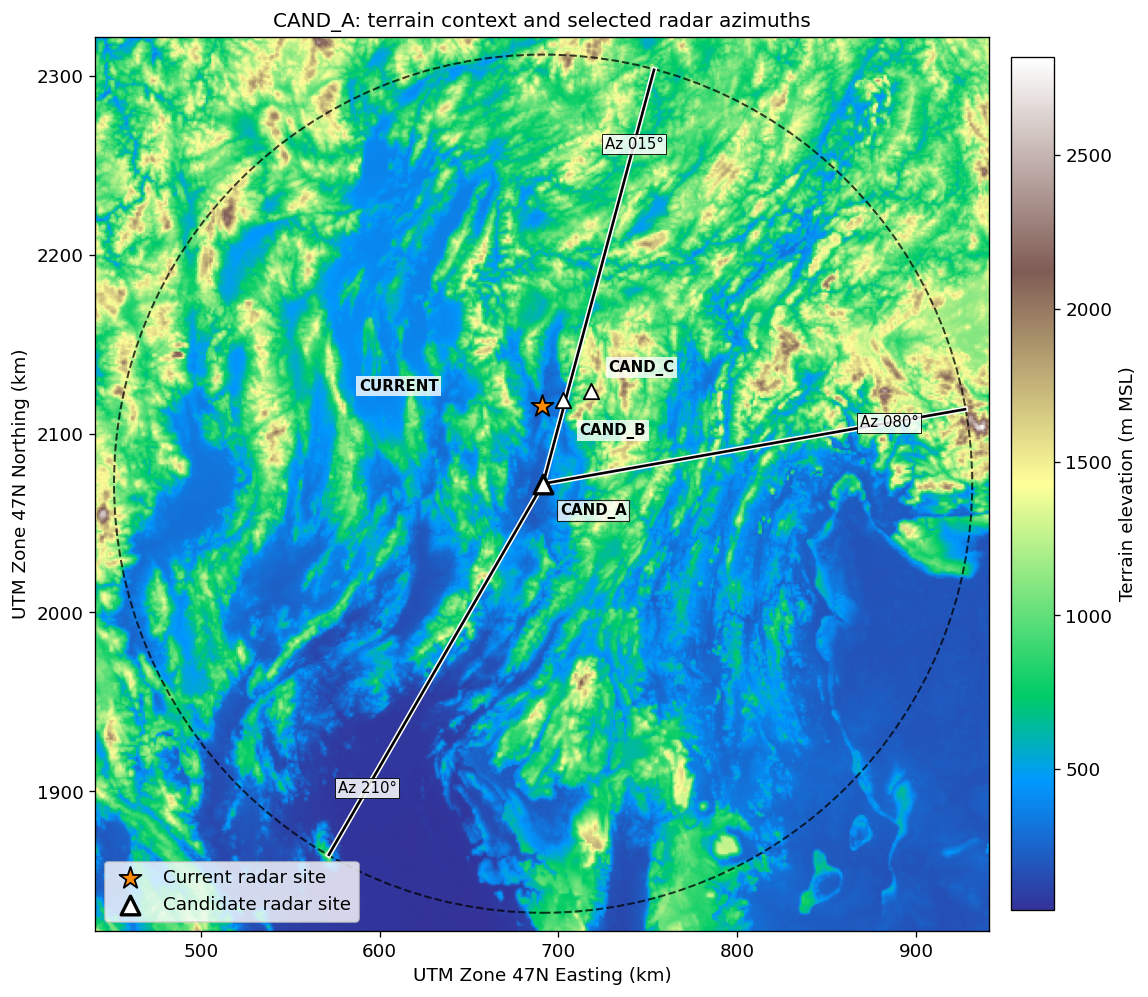

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig03_01_CAND_A_Selected_Azimuths_Terrain_Map.png


In [13]:

# ============================================================
# STEP 13 — Figure 1: terrain map with selected azimuth rays
# ============================================================

# Use a 250-km display radius around the focus site.
display_radius_m = 250_000.0

map_xmin = RADAR_X_M - display_radius_m
map_xmax = RADAR_X_M + display_radius_m
map_ymin = RADAR_Y_M - display_radius_m
map_ymax = RADAR_Y_M + display_radius_m

with rasterio.open(
    DEM_PATH
) as ds:
    map_window = (
        rasterio.windows
        .from_bounds(
            map_xmin,
            map_ymin,
            map_xmax,
            map_ymax,
            transform=ds.transform,
        )
        .round_offsets()
        .round_lengths()
    )

    map_dem = ds.read(
        1,
        window=map_window,
        masked=True,
    )

    map_bounds = (
        rasterio.windows
        .bounds(
            map_window,
            ds.transform,
        )
    )

map_extent_km = [
    map_bounds[0] / 1000.0,
    map_bounds[2] / 1000.0,
    map_bounds[1] / 1000.0,
    map_bounds[3] / 1000.0,
]

label_offsets = {
    "CURRENT": (-62, 12),
    "CAND_A": (10, -16),
    "CAND_B": (10, -18),
    "CAND_C": (10, 14),
}

fig, ax = plt.subplots(
    figsize=(10.0, 9.0)
)

im = ax.imshow(
    map_dem,
    cmap=DEM_CMAP,
    extent=map_extent_km,
    origin="upper",
)

# 240-km range ring for the focus site.
range_ring = Circle(
    (
        RADAR_X_M / 1000.0,
        RADAR_Y_M / 1000.0,
    ),
    MAX_RANGE_M / 1000.0,
    fill=False,
    linewidth=1.2,
    linestyle="--",
    edgecolor="black",
    alpha=0.75,
)
ax.add_patch(range_ring)

# Plot all radar sites.
for _, site in sites.iterrows():
    x_km = (
        float(site["utm_x_m"])
        / 1000.0
    )

    y_km = (
        float(site["utm_y_m"])
        / 1000.0
    )

    is_focus = (
        site["site_id"]
        == FOCUS_SITE_ID
    )

    if site["status"] == "Existing":
        ax.scatter(
            x_km,
            y_km,
            marker=CURRENT_MARKER,
            s=190,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=9,
            label="Current radar site",
        )
    else:
        ax.scatter(
            x_km,
            y_km,
            marker=CANDIDATE_MARKER,
            s=125 if is_focus else 85,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=2.0 if is_focus else 1.1,
            zorder=9,
            label="Candidate radar site",
        )

    dx, dy = label_offsets.get(
        site["site_id"],
        (8, 8),
    )

    ax.annotate(
        site["site_id"],
        xy=(x_km, y_km),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        ha="left" if dx >= 0 else "right",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "black"
            if is_focus else "none",
            "linewidth": 0.7,
            "alpha": 0.80,
            "pad": 1.5,
        },
        zorder=10,
    )

# Selected rays
for az in SELECTED_AZIMUTHS_DEG:
    az_rad = np.deg2rad(
        az
    )

    end_x = (
        RADAR_X_M
        + ground_distance_m[-1]
        * np.sin(az_rad)
    )

    end_y = (
        RADAR_Y_M
        + ground_distance_m[-1]
        * np.cos(az_rad)
    )

    line, = ax.plot(
        [
            RADAR_X_M / 1000.0,
            end_x / 1000.0,
        ],
        [
            RADAR_Y_M / 1000.0,
            end_y / 1000.0,
        ],
        linewidth=1.6,
        color="black",
        zorder=7,
    )

    line.set_path_effects([
        pe.Stroke(
            linewidth=3.4,
            foreground="white",
        ),
        pe.Normal(),
    ])

    label_r = (
        0.82
        * ground_distance_m[-1]
    )

    label_x = (
        RADAR_X_M
        + label_r
        * np.sin(az_rad)
    ) / 1000.0

    label_y = (
        RADAR_Y_M
        + label_r
        * np.cos(az_rad)
    ) / 1000.0

    ax.text(
        label_x,
        label_y,
        f"Az {az:03.0f}°",
        fontsize=9,
        ha="center",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "black",
            "linewidth": 0.6,
            "alpha": 0.85,
            "pad": 1.5,
        },
        zorder=11,
    )

# De-duplicate legend.
handles, labels = (
    ax.get_legend_handles_labels()
)

unique = {}

for h, label in zip(
    handles,
    labels,
):
    if label not in unique:
        unique[label] = h

ax.legend(
    unique.values(),
    unique.keys(),
    loc="lower left",
)

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.84,
    pad=0.02,
)

cbar.set_label(
    "Terrain elevation (m MSL)"
)

ax.set_xlabel(
    "UTM Zone 47N Easting (km)"
)
ax.set_ylabel(
    "UTM Zone 47N Northing (km)"
)
ax.set_title(
    f"{FOCUS_SITE_ID}: terrain context and selected radar azimuths"
)
ax.set_aspect(
    "equal",
    adjustable="box",
)

fig.tight_layout()

fig1_path = (
    FIGURES_DIR /
    f"Fig03_01_{FOCUS_SITE_ID}_"
    "Selected_Azimuths_Terrain_Map.png"
)

fig.savefig(
    fig1_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig1_path)



## 16. Figure 2 — Terrain ใน Radar Coordinates

ภาพนี้ไม่ใช่แผนที่ UTM แต่เป็น representation ใหม่ของ DEM:

- แกน $x$ = ground distance จาก radar
- แกน $y$ = azimuth
- สี = terrain elevation

จึงเป็นภาพของ

$$
T(\alpha,r)
$$

โดยตรง

ภาพนี้ช่วยให้นิสิตเห็นว่าภูเขาหรือ ridge ที่อยู่ในแผนที่ Cartesian จะปรากฏอย่างไรเมื่อมองจากมุมของ radar


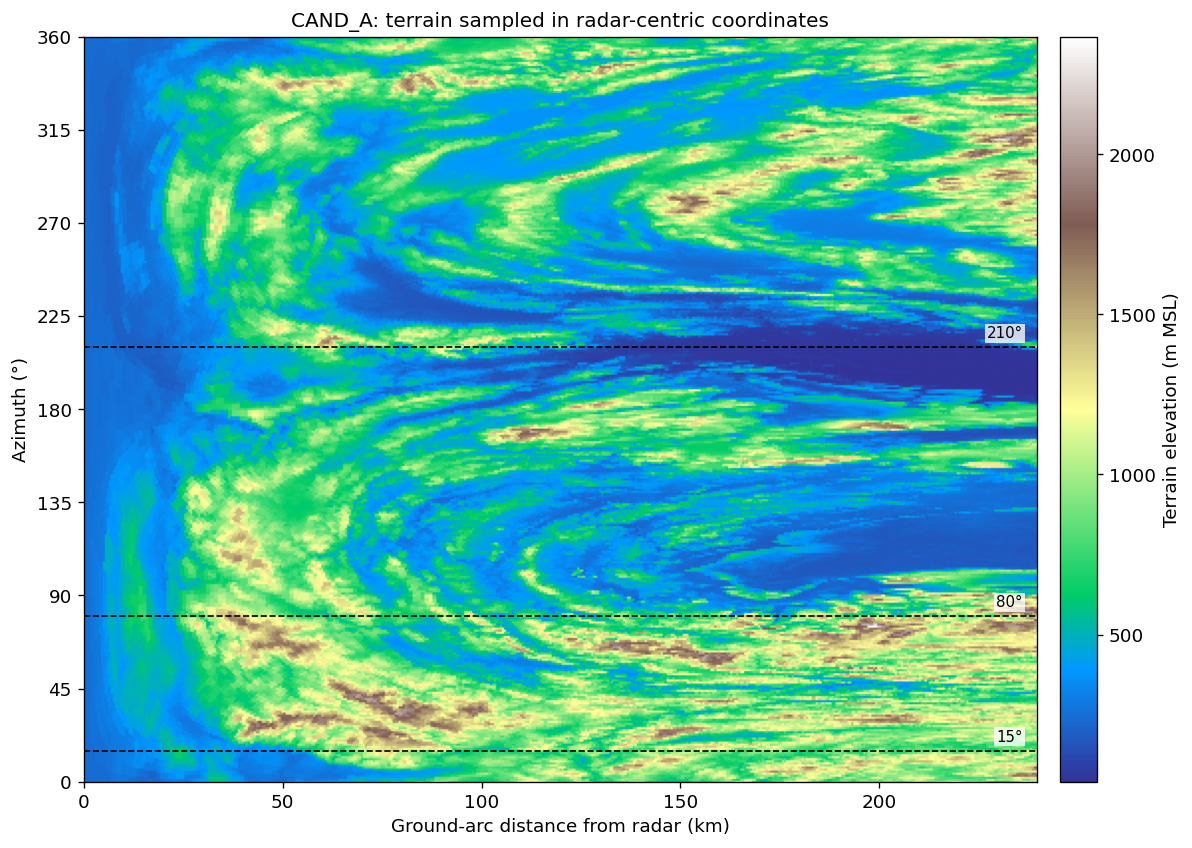

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig03_02_CAND_A_Terrain_Azimuth_Range.png


In [14]:

# ============================================================
# STEP 14 — Figure 2: azimuth–range terrain matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.5, 7.2)
)

im = ax.imshow(
    terrain_msl,
    cmap=DEM_CMAP,
    origin="lower",
    aspect="auto",
    extent=[
        ground_distance_km[0],
        ground_distance_km[-1],
        -0.5,
        359.5,
    ],
)

for az in SELECTED_AZIMUTHS_DEG:
    ax.axhline(
        az,
        linewidth=1.0,
        linestyle="--",
        color="black",
    )

    ax.text(
        ground_distance_km[-1] * 0.985,
        az + 3.0,
        f"{az:.0f}°",
        ha="right",
        va="bottom",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.78,
            "pad": 1.2,
        },
    )

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Terrain elevation (m MSL)"
)

ax.set_xlabel(
    "Ground-arc distance from radar (km)"
)
ax.set_ylabel(
    "Azimuth (°)"
)
ax.set_yticks(
    np.arange(
        0,
        361,
        45,
    )
)
ax.set_xlim(
    0,
    ground_distance_km[-1],
)
ax.set_ylim(
    0,
    360,
)
ax.set_title(
    f"{FOCUS_SITE_ID}: terrain sampled in radar-centric coordinates"
)

fig.tight_layout()

fig2_path = (
    FIGURES_DIR /
    f"Fig03_02_{FOCUS_SITE_ID}_"
    "Terrain_Azimuth_Range.png"
)

fig.savefig(
    fig2_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig2_path)



# Part F — Selected Terrain–Beam Profiles

## 17. ดึง Terrain Profile ตาม Azimuth

สำหรับ azimuth ที่เลือก เราจะดึงแถวที่ตรงกันจาก terrain polar grid แล้วเปรียบเทียบกับ

- lower −3 dB beam edge
- beam centre
- upper −3 dB beam edge

สำหรับ nominal elevation

$$
0.5^\circ
$$

นี่คือขั้นตอนที่ทำให้เห็น **terrain–beam interaction** โดยตรง


In [15]:

# ============================================================
# STEP 15 — Build selected terrain–beam profiles
# ============================================================

beam = beam_edges_msl(
    slant_range_m,
    FOCUS_ELEVATION_DEG,
)

profile_rows = []
diagnostic_rows = []

def first_true_distance_km(
    condition,
    distance_km,
):
    idx = np.flatnonzero(
        condition
    )

    if idx.size == 0:
        return np.nan

    return float(
        distance_km[
            idx[0]
        ]
    )


for az in SELECTED_AZIMUTHS_DEG:
    az_index = int(
        round(az)
    ) % 360

    terrain_profile = (
        terrain_msl[
            az_index,
            :
        ].astype(float)
    )

    center_clearance = (
        beam["center_msl_m"]
        - terrain_profile
    )

    lower_clearance = (
        beam["lower_msl_m"]
        - terrain_profile
    )

    upper_clearance = (
        beam["upper_msl_m"]
        - terrain_profile
    )

    finite = np.isfinite(
        terrain_profile
    )

    # Geometric intersections only.
    lower_intersection = (
        finite
        & (lower_clearance <= 0.0)
    )

    center_intersection = (
        finite
        & (center_clearance <= 0.0)
    )

    for i in range(NBINS):
        profile_rows.append({
            "site_id": FOCUS_SITE_ID,
            "azimuth_deg": az,
            "nominal_elevation_deg": FOCUS_ELEVATION_DEG,
            "slant_range_km": slant_range_km[i],
            "ground_distance_km": ground_distance_km[i],
            "terrain_msl_m": terrain_profile[i],
            "beam_lower_msl_m": beam["lower_msl_m"][i],
            "beam_center_msl_m": beam["center_msl_m"][i],
            "beam_upper_msl_m": beam["upper_msl_m"][i],
            "lower_clearance_m": lower_clearance[i],
            "center_clearance_m": center_clearance[i],
            "upper_clearance_m": upper_clearance[i],
        })

    if finite.any():
        finite_center = center_clearance[
            finite
        ]

        finite_lower = lower_clearance[
            finite
        ]

        finite_terrain = terrain_profile[
            finite
        ]

        finite_distance = ground_distance_km[
            finite
        ]

        min_center_idx = np.argmin(
            finite_center
        )

        min_lower_idx = np.argmin(
            finite_lower
        )

        max_terrain_idx = np.argmax(
            finite_terrain
        )

        diagnostic_rows.append({
            "site_id": FOCUS_SITE_ID,
            "azimuth_deg": az,
            "nominal_elevation_deg": FOCUS_ELEVATION_DEG,
            "maximum_terrain_msl_m": float(
                finite_terrain[
                    max_terrain_idx
                ]
            ),
            "range_of_maximum_terrain_km": float(
                finite_distance[
                    max_terrain_idx
                ]
            ),
            "minimum_center_clearance_m": float(
                finite_center[
                    min_center_idx
                ]
            ),
            "range_of_min_center_clearance_km": float(
                finite_distance[
                    min_center_idx
                ]
            ),
            "minimum_lower_edge_clearance_m": float(
                finite_lower[
                    min_lower_idx
                ]
            ),
            "range_of_min_lower_clearance_km": float(
                finite_distance[
                    min_lower_idx
                ]
            ),
            "first_lower_edge_intersection_km": (
                first_true_distance_km(
                    lower_intersection,
                    ground_distance_km,
                )
            ),
            "first_centerline_intersection_km": (
                first_true_distance_km(
                    center_intersection,
                    ground_distance_km,
                )
            ),
        })

selected_profiles = pd.DataFrame(
    profile_rows
)

profile_diagnostics = pd.DataFrame(
    diagnostic_rows
)

display(
    profile_diagnostics.style.format({
        "azimuth_deg": "{:.0f}",
        "nominal_elevation_deg": "{:.1f}",
        "maximum_terrain_msl_m": "{:.1f}",
        "range_of_maximum_terrain_km": "{:.1f}",
        "minimum_center_clearance_m": "{:.1f}",
        "range_of_min_center_clearance_km": "{:.1f}",
        "minimum_lower_edge_clearance_m": "{:.1f}",
        "range_of_min_lower_clearance_km": "{:.1f}",
        "first_lower_edge_intersection_km": "{:.1f}",
        "first_centerline_intersection_km": "{:.1f}",
    })
)

profiles_csv = (
    TABLES_DIR /
    f"03_{FOCUS_SITE_ID}_"
    "Selected_Azimuth_Terrain_Beam_Profiles.csv"
)

diagnostics_csv = (
    TABLES_DIR /
    f"03_{FOCUS_SITE_ID}_"
    "Selected_Azimuth_Geometric_Diagnostics.csv"
)

selected_profiles.to_csv(
    profiles_csv,
    index=False,
)

profile_diagnostics.to_csv(
    diagnostics_csv,
    index=False,
)

print("\nSaved:")
print(profiles_csv)
print(diagnostics_csv)


,site_id,azimuth_deg,nominal_elevation_deg,maximum_terrain_msl_m,range_of_maximum_terrain_km,minimum_center_clearance_m,range_of_min_center_clearance_km,minimum_lower_edge_clearance_m,range_of_min_lower_clearance_km,first_lower_edge_intersection_km,first_centerline_intersection_km
0,CAND_A,15,0.5,1399.0,76.7,-141.8,24.2,-787.3,76.7,6.2,19.7
1,CAND_A,80,0.5,1629.0,36.2,-970.3,36.2,-1286.7,36.2,1.7,2.7
2,CAND_A,210,0.5,1461.0,59.2,-472.4,59.2,-989.4,59.2,24.7,55.2



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/03_CAND_A_Selected_Azimuth_Terrain_Beam_Profiles.csv
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/03_CAND_A_Selected_Azimuth_Geometric_Diagnostics.csv



## 18. Figures 3–5 — Terrain–Beam Profile ราย Azimuth

แต่ละภาพจะสร้างเป็น **figure แยกกัน** เพื่อให้

- อ่านง่ายใน Colab
- ใช้ใน lecture slides ได้
- export ไปปรับสำหรับ publication ได้
- ไม่อัดข้อมูลหลายทิศไว้ใน panel เดียวจนแน่นเกินไป

พื้นที่ภูมิประเทศจะแสดงเทียบกับ beam centre และ −3 dB edges บนแกนระดับ MSL เดียวกัน


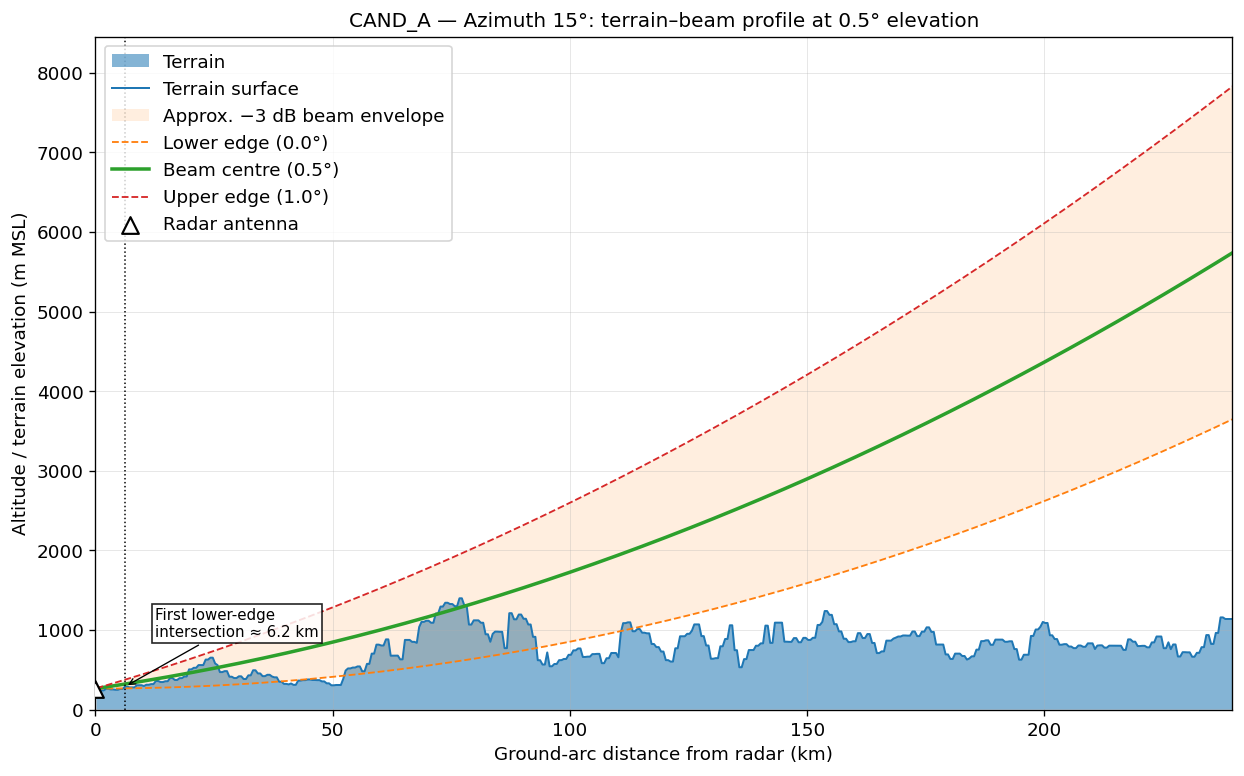

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig03_03_CAND_A_Az015_Terrain_Beam_Profile.png


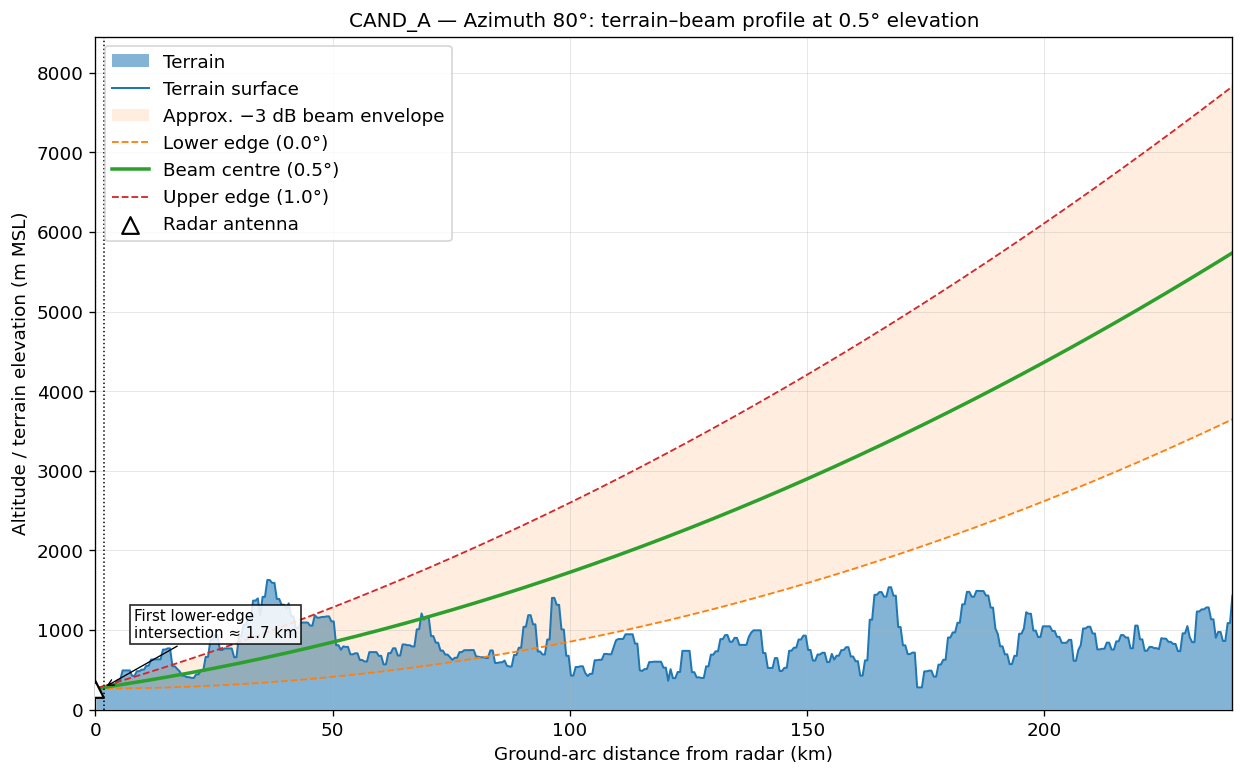

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig03_04_CAND_A_Az080_Terrain_Beam_Profile.png


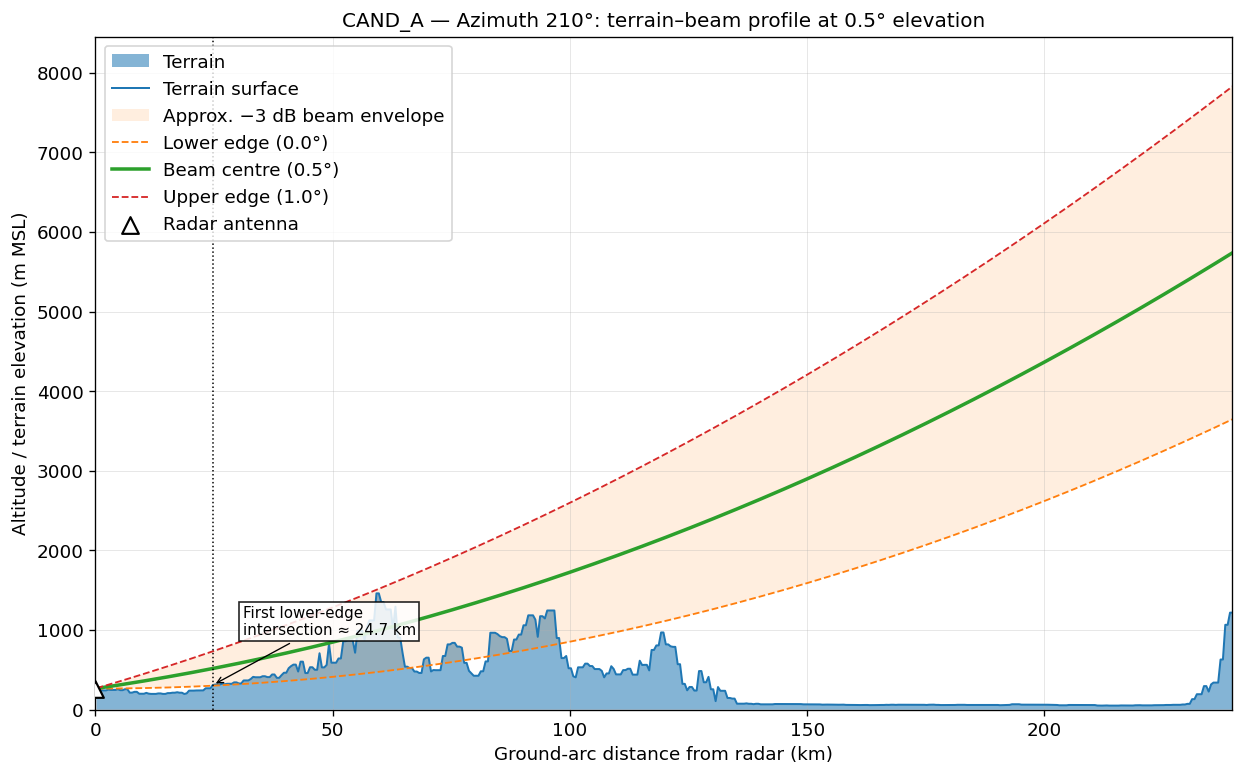

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig03_05_CAND_A_Az210_Terrain_Beam_Profile.png


In [16]:

# ============================================================
# STEP 16 — Figures 3–5: terrain–beam profiles
# ============================================================

profile_figure_paths = []

for figure_number, az in enumerate(
    SELECTED_AZIMUTHS_DEG,
    start=3,
):
    subset = (
        selected_profiles[
            selected_profiles[
                "azimuth_deg"
            ] == az
        ]
        .sort_values(
            "ground_distance_km"
        )
        .copy()
    )

    x = (
        subset[
            "ground_distance_km"
        ].to_numpy()
    )

    terrain = (
        subset[
            "terrain_msl_m"
        ].to_numpy()
    )

    lower = (
        subset[
            "beam_lower_msl_m"
        ].to_numpy()
    )

    center = (
        subset[
            "beam_center_msl_m"
        ].to_numpy()
    )

    upper = (
        subset[
            "beam_upper_msl_m"
        ].to_numpy()
    )

    fig, ax = plt.subplots(
        figsize=(10.5, 6.6)
    )

    # Terrain profile
    ax.fill_between(
        x,
        0.0,
        terrain,
        alpha=0.55,
        label="Terrain",
    )

    ax.plot(
        x,
        terrain,
        linewidth=1.2,
        label="Terrain surface",
    )

    # Beam envelope
    ax.fill_between(
        x,
        lower,
        upper,
        alpha=0.13,
        label="Approx. −3 dB beam envelope",
    )

    ax.plot(
        x,
        lower,
        linewidth=1.1,
        linestyle="--",
        label=(
            f"Lower edge "
            f"({beam['lower_angle_deg']:.1f}°)"
        ),
    )

    ax.plot(
        x,
        center,
        linewidth=2.1,
        label=(
            f"Beam centre "
            f"({FOCUS_ELEVATION_DEG:.1f}°)"
        ),
    )

    ax.plot(
        x,
        upper,
        linewidth=1.1,
        linestyle="--",
        label=(
            f"Upper edge "
            f"({beam['upper_angle_deg']:.1f}°)"
        ),
    )

    # Radar antenna reference
    ax.scatter(
        [0.0],
        [RADAR_ANTENNA_MSL_M],
        marker="^",
        s=100,
        facecolor="white",
        edgecolor="black",
        linewidth=1.3,
        zorder=10,
        label="Radar antenna",
    )

    diag = (
        profile_diagnostics[
            profile_diagnostics[
                "azimuth_deg"
            ] == az
        ]
        .iloc[0]
    )

    # Annotate first lower-edge intersection if present.
    first_lower = (
        diag[
            "first_lower_edge_intersection_km"
        ]
    )

    if np.isfinite(
        first_lower
    ):
        idx = np.argmin(
            np.abs(
                x - first_lower
            )
        )

        ax.axvline(
            first_lower,
            linewidth=0.9,
            linestyle=":",
            color="black",
        )

        ax.annotate(
            (
                "First lower-edge\n"
                f"intersection ≈ {first_lower:.1f} km"
            ),
            xy=(
                first_lower,
                terrain[idx],
            ),
            xytext=(
                18,
                30,
            ),
            textcoords="offset points",
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 0.8,
            },
            fontsize=9,
            bbox={
                "facecolor": "white",
                "edgecolor": "black",
                "alpha": 0.85,
                "pad": 2.0,
            },
        )

    finite_values = np.concatenate([
        terrain[
            np.isfinite(terrain)
        ],
        upper[
            np.isfinite(upper)
        ],
    ])

    y_max = (
        np.nanmax(
            finite_values
        )
        if finite_values.size
        else 5000.0
    )

    ax.set_xlim(
        0,
        ground_distance_km[-1],
    )

    ax.set_ylim(
        0,
        y_max * 1.08,
    )

    ax.set_xlabel(
        "Ground-arc distance from radar (km)"
    )

    ax.set_ylabel(
        "Altitude / terrain elevation (m MSL)"
    )

    ax.set_title(
        f"{FOCUS_SITE_ID} — Azimuth {az:.0f}°: "
        f"terrain–beam profile at {FOCUS_ELEVATION_DEG:.1f}° elevation"
    )

    ax.grid(
        True,
        linewidth=0.4,
        alpha=0.45,
    )

    ax.legend(
        loc="upper left",
    )

    fig.tight_layout()

    az_tag = (
        f"{int(round(az)) % 360:03d}"
    )

    fig_path = (
        FIGURES_DIR /
        f"Fig03_{figure_number:02d}_"
        f"{FOCUS_SITE_ID}_Az{az_tag}_"
        "Terrain_Beam_Profile.png"
    )

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    profile_figure_paths.append(
        str(fig_path)
    )

    print("Saved:", fig_path)



# Part G — Clearance Diagnostics

## 19. ทำไมต้องดู Clearance แยกจาก Profile?

Terrain–beam profile ช่วยให้เห็นภาพรวม แต่ในบางกรณีความต่างระดับเพียงหลักสิบเมตรมองด้วยตาได้ยาก

เราจึง plot

$$
C_{\mathrm{center}}
$$

และ

$$
C_{\mathrm{lower}}
$$

โดยใช้เส้นอ้างอิง

$$
C=0
$$

เพื่อแยกพื้นที่ที่ terrain ต่ำกว่า/สูงกว่าเส้น beam ที่พิจารณา

> ค่านี้ยังเป็น **geometric clearance** ไม่ใช่ blockage fraction


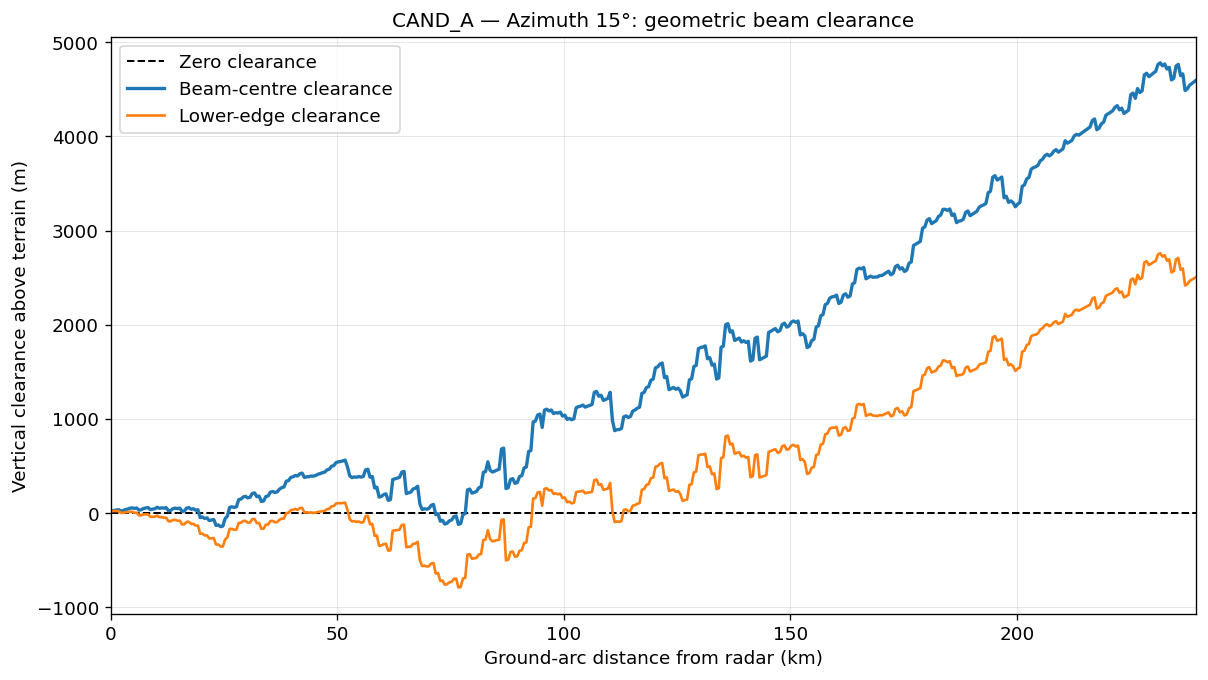

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig03_06_CAND_A_Az015_Geometric_Clearance.png


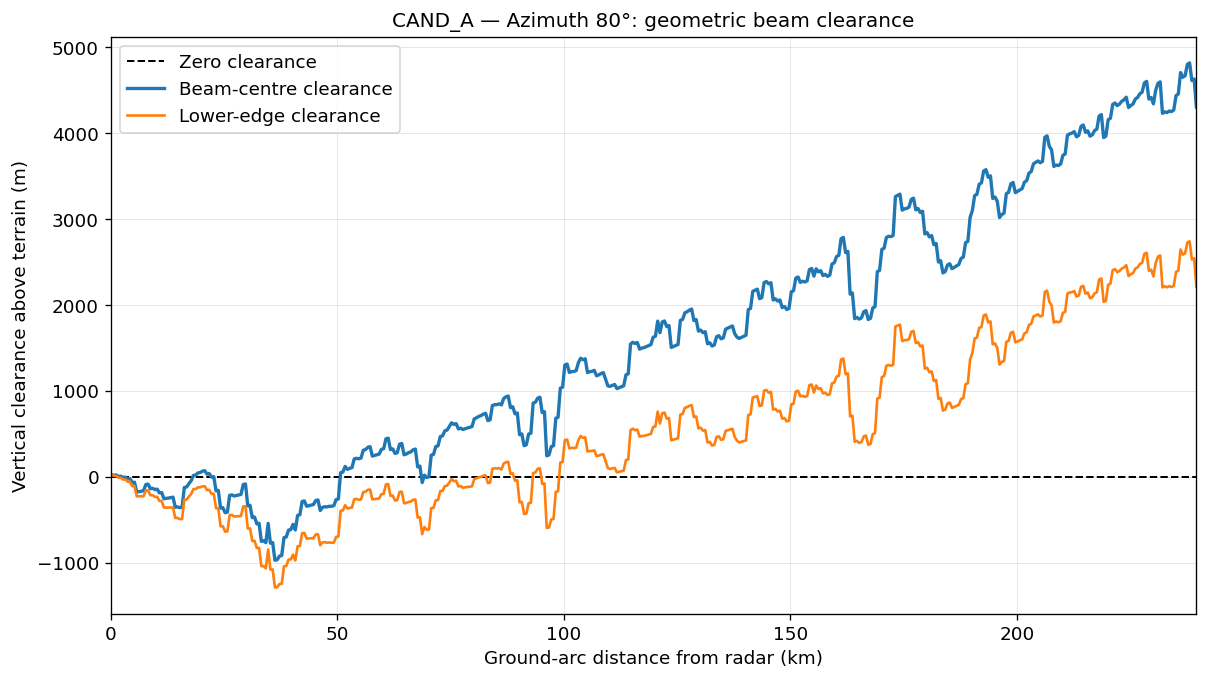

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig03_07_CAND_A_Az080_Geometric_Clearance.png


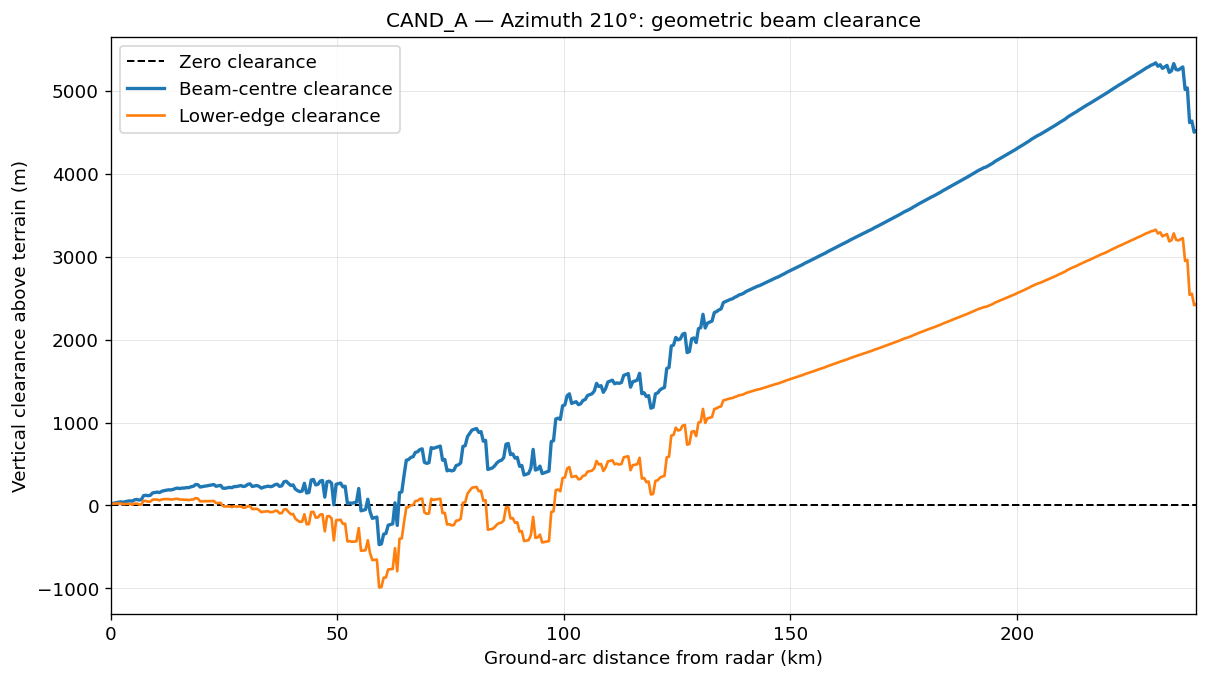

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig03_08_CAND_A_Az210_Geometric_Clearance.png


In [17]:

# ============================================================
# STEP 17 — Figures 6–8: clearance diagnostics
# ============================================================

clearance_figure_paths = []

for figure_number, az in enumerate(
    SELECTED_AZIMUTHS_DEG,
    start=6,
):
    subset = (
        selected_profiles[
            selected_profiles[
                "azimuth_deg"
            ] == az
        ]
        .sort_values(
            "ground_distance_km"
        )
        .copy()
    )

    x = (
        subset[
            "ground_distance_km"
        ].to_numpy()
    )

    center_clear = (
        subset[
            "center_clearance_m"
        ].to_numpy()
    )

    lower_clear = (
        subset[
            "lower_clearance_m"
        ].to_numpy()
    )

    fig, ax = plt.subplots(
        figsize=(10.2, 5.8)
    )

    ax.axhline(
        0.0,
        linewidth=1.2,
        linestyle="--",
        color="black",
        label="Zero clearance",
    )

    ax.plot(
        x,
        center_clear,
        linewidth=2.0,
        label="Beam-centre clearance",
    )

    ax.plot(
        x,
        lower_clear,
        linewidth=1.6,
        label="Lower-edge clearance",
    )

    ax.set_xlim(
        0,
        ground_distance_km[-1],
    )

    ax.set_xlabel(
        "Ground-arc distance from radar (km)"
    )

    ax.set_ylabel(
        "Vertical clearance above terrain (m)"
    )

    ax.set_title(
        f"{FOCUS_SITE_ID} — Azimuth {az:.0f}°: "
        "geometric beam clearance"
    )

    ax.grid(
        True,
        linewidth=0.4,
        alpha=0.45,
    )

    ax.legend(
        loc="best",
    )

    fig.tight_layout()

    az_tag = (
        f"{int(round(az)) % 360:03d}"
    )

    fig_path = (
        FIGURES_DIR /
        f"Fig03_{figure_number:02d}_"
        f"{FOCUS_SITE_ID}_Az{az_tag}_"
        "Geometric_Clearance.png"
    )

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    clearance_figure_paths.append(
        str(fig_path)
    )

    print("Saved:", fig_path)



## 20. วิธีอ่านผล Profile Diagnostics

ค่าที่สำคัญมีดังนี้

### Maximum terrain elevation

บอกยอด terrain สูงสุดที่ ray ผ่าน แต่ไม่จำเป็นต้องเป็น obstacle ที่สำคัญที่สุด เพราะยอดเขาสูงมากแต่ไกล radar อาจอยู่ต่ำกว่า beam มาก

### Minimum centre clearance

$$
\min(C_{\mathrm{center}})
$$

บอกตำแหน่งที่ terrain เข้าใกล้ beam centre มากที่สุด

### Minimum lower-edge clearance

$$
\min(C_{\mathrm{lower}})
$$

มีความไวต่อ terrain penetration มากกว่า beam centre

### First lower-edge intersection

ระยะแรกที่

$$
C_{\mathrm{lower}}\le0
$$

แสดงว่า terrain เริ่มเข้าสู่ approximate half-power beam envelope

### First centreline intersection

ระยะแรกที่

$$
C_{\mathrm{center}}\le0
$$

เป็นสถานการณ์ที่รุนแรงกว่าในเชิง geometry

แต่ทั้งสองค่ายัง **ไม่ใช่ D10 หรือ D50** เพราะ D10/D50 จะนิยามจาก CBB ในบทขั้นสูง



## 21. สิ่งที่เรายังไม่ควรสรุป

Notebook นี้ยังไม่ควรใช้ตัดสินว่า CAND_A เหมาะสมหรือไม่เหมาะสมเป็นสถานีสุดท้าย

เหตุผลคือเราเพิ่งตรวจ 3 selected azimuths และ elevation หลักเพียงหนึ่งค่า

การตัดสิน site ต้องพิจารณา

$$
360^\circ
\times
\text{multiple elevations}
\times
\text{beam-blockage metric}
$$

และควรเปรียบเทียบระหว่าง

- CURRENT
- CAND_A
- CAND_B
- CAND_C

ภายใต้ geometry และ terrain-processing assumptions เดียวกัน

Notebook นี้มีหน้าที่สอน **mechanism** ก่อนเข้าสู่ quantitative blockage analysis



## 22. แบบฝึกคิด

### CORE

1. อธิบายเหตุผลที่สมการ UTM ใช้ $E=E_0+d\sin\alpha$ และ $N=N_0+d\cos\alpha$
2. เปรียบเทียบ terrain profile ของ azimuth 15°, 80° และ 210° ว่าทิศใดมีภูมิประเทศสูงใกล้ radar มากกว่า
3. ทิศใดมี minimum lower-edge clearance ต่ำที่สุด?
4. หาก $C_{\mathrm{lower}}<0$ แต่ $C_{\mathrm{center}}>0$ หมายความว่าอย่างไร?

### ADVANCED

5. เปลี่ยน selected azimuth เป็นทิศที่นิสิตสนใจ แล้วอธิบาย terrain–beam interaction
6. ทดลองเปลี่ยน elevation จาก 0.5° เป็น 1.0° แล้วตรวจว่า geometric intersection เปลี่ยนอย่างไร
7. อธิบายว่าทำไมการใช้ bilinear interpolation กับ 1-km MAX DEM อาจเปลี่ยน ridge representation

### RESEARCH EXTENSION

8. เสนอวิธีเปรียบเทียบ terrain–beam clearance ครบ 360° โดยไม่ใช้เพียง selected rays
9. หากใช้ DEM 250 m แทน 1 km คาดว่า first intersection จะเปลี่ยนอย่างไรในภูมิประเทศภูเขา?
10. อธิบายว่าทำไม “site สูงที่สุด” ไม่จำเป็นต้องเป็น “site ที่ radar visibility ดีที่สุด”


In [18]:

# ============================================================
# STEP 18 — Save metadata and final readiness check
# ============================================================

metadata = {
    "site_id": FOCUS_SITE_ID,
    "site_name": str(
        focus_site["site_name"]
    ),
    "radar_x_m": RADAR_X_M,
    "radar_y_m": RADAR_Y_M,
    "native_ground_msl_m": RADAR_GROUND_MSL_M,
    "antenna_agl_teaching_assumption_m": ANTENNA_AGL_M,
    "antenna_msl_teaching_m": RADAR_ANTENNA_MSL_M,
    "terrain_dem": str(
        DEM_PATH
    ),
    "terrain_sampling_method": (
        "Containing raster cell / no additional interpolation"
    ),
    "terrain_dem_resampling_history": (
        "1-km UTM MAX-elevation DEM from Notebook 01"
    ),
    "reference_elevation_deg": FOCUS_ELEVATION_DEG,
    "beamwidth_deg": BEAMWIDTH_DEG,
    "k_factor": K_STANDARD,
    "earth_radius_m": EARTH_RADIUS_M,
    "selected_azimuths_deg": [
        float(v)
        for v in SELECTED_AZIMUTHS_DEG
    ],
    "number_of_azimuths": int(
        azimuth_deg.size
    ),
    "number_of_range_gates": int(
        slant_range_m.size
    ),
    "range_gate_reference": "gate centre",
    "maximum_nominal_slant_range_km": (
        MAX_RANGE_M / 1000.0
    ),
    "maximum_sampled_ground_arc_km": float(
        ground_distance_km[-1]
    ),
    "polar_terrain_npz": str(
        polar_npz
    ),
    "selected_profiles_csv": str(
        profiles_csv
    ),
    "diagnostics_csv": str(
        diagnostics_csv
    ),
}

metadata_json = (
    METADATA_DIR /
    f"03_{FOCUS_SITE_ID}_"
    "Terrain_Beam_Profile_Metadata.json"
)

with open(
    metadata_json,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False,
    )

selected_az_indices = [
    int(round(v)) % 360
    for v in SELECTED_AZIMUTHS_DEG
]

selected_valid_fraction = (
    np.isfinite(
        terrain_msl[
            selected_az_indices,
            :
        ]
    ).mean()
)

final_checks = {
    "1-km DEM loaded": DEM_PATH.exists(),
    "Focus site found": len(focus_match) == 1,
    "360 azimuth rays created": azimuth_deg.size == 360,
    "480 gate centres created": slant_range_m.size == NBINS,
    "Polar grid shape is 360 × 480": (
        terrain_msl.shape == (360, NBINS)
    ),
    "≥99% valid terrain samples": (
        valid_fraction >= 0.99
    ),
    "Selected rays have ≥99% valid terrain": (
        selected_valid_fraction >= 0.99
    ),
    "Polar terrain NPZ saved": polar_npz.exists(),
    "Selected profile CSV saved": profiles_csv.exists(),
    "Diagnostics CSV saved": diagnostics_csv.exists(),
    "Metadata JSON saved": metadata_json.exists(),
}

print("=" * 82)
print("NOTEBOOK 03 — FINAL READINESS CHECK")
print("=" * 82)

all_ok = True

for label, status in final_checks.items():
    print(
        ("✓" if status else "✗"),
        label,
    )
    all_ok = (
        all_ok and status
    )

print("=" * 82)

print(
    "\nOverall valid terrain samples:",
    f"{100.0*valid_fraction:.3f}%"
)

print(
    "Selected-ray valid samples:",
    f"{100.0*selected_valid_fraction:.3f}%"
)

print("\nKey outputs")
print("-----------")
print("Polar terrain :", polar_npz)
print("Profiles      :", profiles_csv)
print("Diagnostics   :", diagnostics_csv)
print("Metadata      :", metadata_json)

if all_ok:
    print(
        "\n✓ TERRAIN–BEAM PROFILES READY — proceed to "
        "Notebook 04: Partial and Cumulative Beam Blockage."
    )
else:
    raise RuntimeError(
        "One or more terrain-sampling QC checks failed."
    )


NOTEBOOK 03 — FINAL READINESS CHECK
✓ 1-km DEM loaded
✓ Focus site found
✓ 360 azimuth rays created
✓ 480 gate centres created
✓ Polar grid shape is 360 × 480
✓ ≥99% valid terrain samples
✓ Selected rays have ≥99% valid terrain
✓ Polar terrain NPZ saved
✓ Selected profile CSV saved
✓ Diagnostics CSV saved
✓ Metadata JSON saved

Overall valid terrain samples: 100.000%
Selected-ray valid samples: 100.000%

Key outputs
-----------
Polar terrain : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/03_CAND_A_TerrainPolar_0p5deg_360x480.npz
Profiles      : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/03_CAND_A_Selected_Azimuth_Terrain_Beam_Profiles.csv
Diagnostics   : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/03_CAND_A_Selected_Azimuth_Geometric_Diagnostics.csv
Metadata      : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/03_CAND_A_Terrain_Beam_Profile_Metadata.json

✓ TERRAIN–BEAM PROFILES READY —


# 23. สรุปบทเรียน

Notebook นี้เป็นจุดเชื่อมสำคัญระหว่าง **GIS** และ **Radar Meteorology**

เราเริ่มจาก DEM แบบ Cartesian:

$$
DEM(E,N)
$$

สร้าง radar-centric gate coordinates:

$$
(E,N)
=
f(d,\alpha)
$$

แล้ว sample terrain เป็น

$$
T(\alpha,r)
$$

จากนั้นนำ beam geometry จาก Notebook 02 มาเปรียบเทียบกับ terrain:

$$
H_{\mathrm{terrain}}
\quad\text{vs}\quad
H_{\mathrm{beam,lower}}
,\;
H_{\mathrm{beam,center}}
,\;
H_{\mathrm{beam,upper}}
$$

และคำนวณ geometric clearance:

$$
C
=
H_{\mathrm{beam}}
-
H_{\mathrm{terrain}}
$$

### สิ่งสำคัญที่สุด

$$
\boxed{
\text{Terrain penetrating the beam envelope}
\neq
\text{PBB/CBB}
}
$$

Notebook 03 แสดง **geometry of interaction**

Notebook 04 จึงจะเพิ่มการคำนวณว่า **หน้าตัดลำบีมถูก terrain บังเป็นสัดส่วนเท่าใด** และการบดบังนั้นสะสมไปตาม ray อย่างไร

---

## Next — Notebook 04

### Partial Beam Blockage (PBB)

$$
PBB
=
\frac{
A_{\mathrm{blocked}}
}{
A_{\mathrm{beam}}
}
$$

### Cumulative Beam Blockage (CBB)

พิจารณาการบดบังสะสมตามแนว radar ray

และจะเริ่มใช้ `wradlib` อย่างมีความหมายทางฟิสิกส์ หลังจากที่นิสิตเข้าใจ terrain–beam geometry แล้ว
